In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/perovskite_features.csv")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"

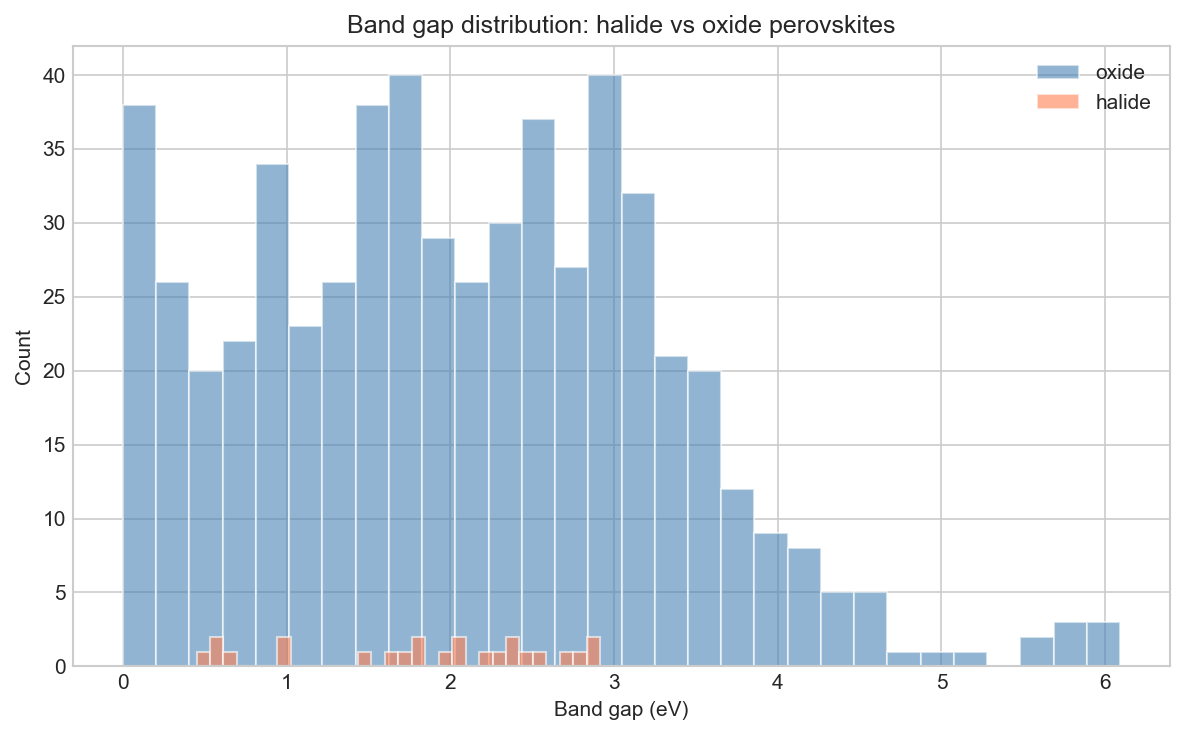

In [14]:
fig, ax = plt.subplots(figsize=(8,5))

for family,color in zip(["oxide","halide"],["steelblue","coral"]):
    subset = df[df["family"]==family]["band_gap"]
    ax.hist(subset,bins=30,alpha=0.6,label=family,color=color,edgecolor="white")

ax.set_xlabel("Band gap (eV)")
ax.set_ylabel("Count")
ax.set_title("Band gap distribution: halide vs oxide perovskites")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig1_bandgap_distribution.png",dpi=150)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

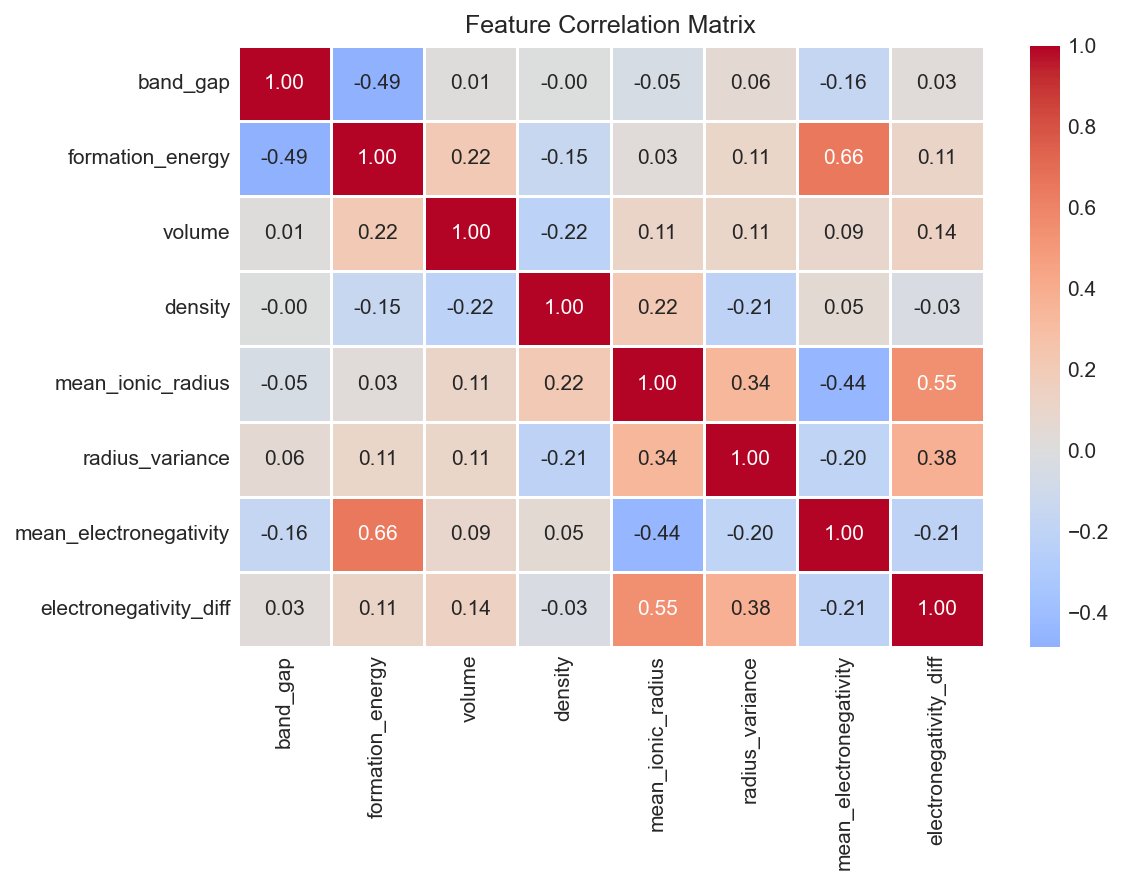

In [3]:
fig, ax = plt.subplots(figsize=(8,6))

numeric_cols = ["band_gap","formation_energy","volume","density",
                "mean_ionic_radius","radius_variance",
                "mean_electronegativity","electronegativity_diff"]

corre = df[numeric_cols].corr()
sns.heatmap(corre,annot=True,fmt=".2f",cmap="coolwarm",
            center=0,ax=ax,linewidth=0.5)

ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("figures/fig2_correlation_heatmap.png",dpi=150)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

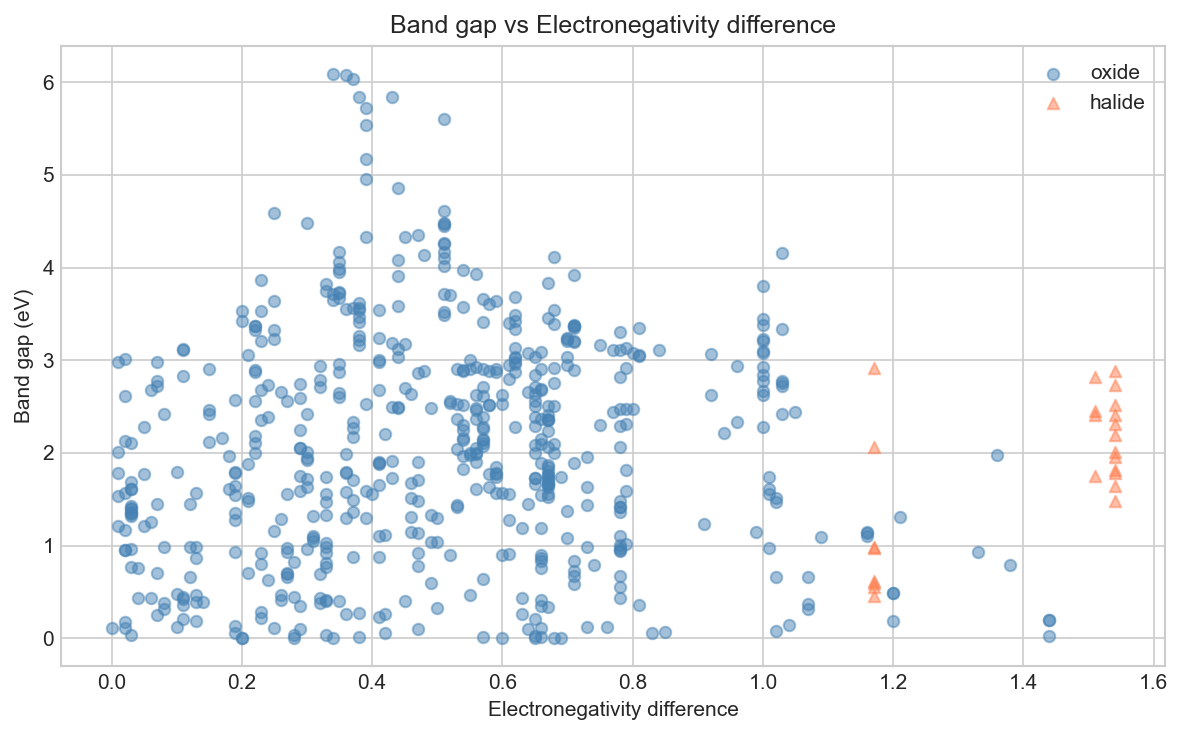

In [4]:
fig,ax = plt.subplots(figsize=(8,5))

for family,color,marker in zip(["oxide","halide"],["steelblue","coral"],["o","^"]):
    subset = df[df["family"]==family]
    ax.scatter(subset["electronegativity_diff"],subset["band_gap"],
               alpha=0.5,label=family,color=color,marker=marker,s=30)

ax.set_xlabel("Electronegativity difference")
ax.set_ylabel("Band gap (eV)")
ax.set_title("Band gap vs Electronegativity difference")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig3_bandgap_vs_electronegativity.png",dpi=150)
plt.show

/var/folders/7b/l4bd8yf50b9_zt4ms77_l52w0000gn/T/ipykernel_56341/3926708501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="family",y="band_gap",


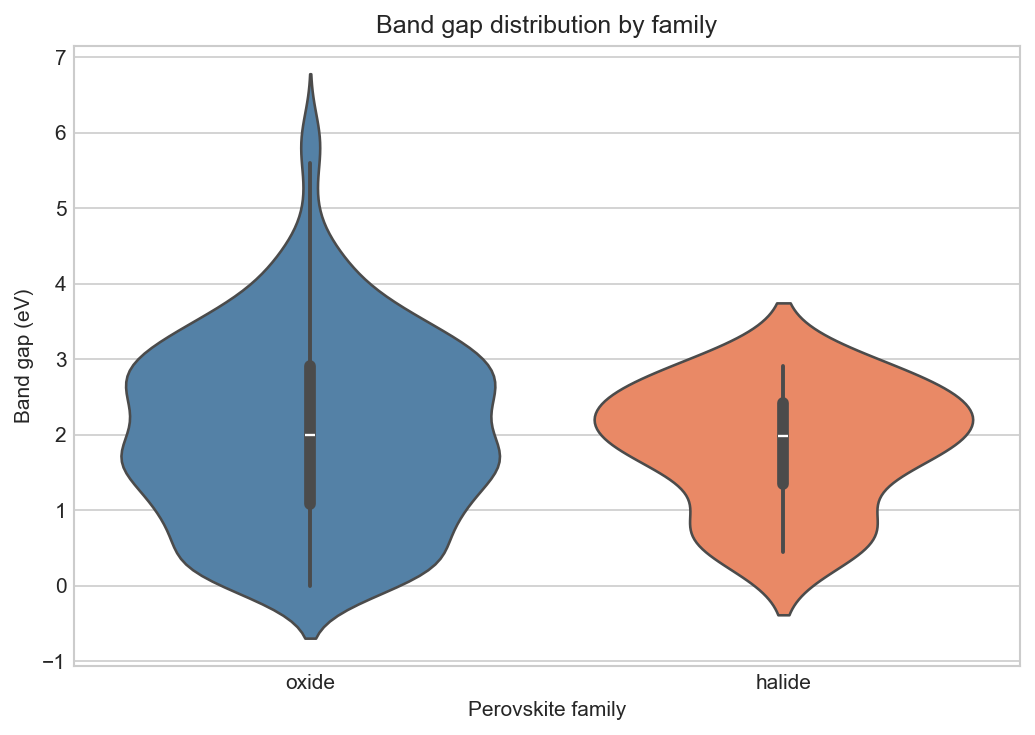

In [7]:
fig, ax = plt.subplots(figsize=(7,5))

sns.violinplot(data=df,x="family",y="band_gap",
               palette={"oxide":"steelblue","halide":"coral"},
               inner="box",ax=ax)
ax.set_xlabel("Perovskite family")
ax.set_ylabel("Band gap (eV)")
ax.set_title("Band gap distribution by family")
plt.tight_layout()
plt.savefig("figures/fig4_violin_bandgap.png",dpi=150)
plt.show()